<a href="https://colab.research.google.com/github/Mldyalaura/KELAS_BIGDATA/blob/main/UAS_PRAKBIGDATA__HEWAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter
import tensorflow as tf
from tensorflow.keras import layers, models

# Agar hasil percobaan lebih konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ==========================================================
# MEMBUAT DATASET CITRA HEWAN SECARA OTOMATIS
# Kelas: Ikan, Kelinci, Ayam
# Jumlah gambar per kelas: 200
# Ukuran gambar: 160x160 px
# ==========================================================

import os
import shutil
import random
import numpy as np
from PIL import Image, ImageDraw, ImageFilter

IMG_SIZE = 160
JUMLAH_GAMBAR_PER_KELAS = 200
BASE_DIR = "/content/dataset_hewan"
KELAS_HEWAN = ["ikan", "kelinci", "ayam"]

# Hapus dataset lama agar tidak tercampur
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

for nama_kelas in KELAS_HEWAN:
    os.makedirs(os.path.join(BASE_DIR, nama_kelas), exist_ok=True)


# ----------------------------------------------------------
# FUNGSI UMUM
# ----------------------------------------------------------

def tambah_noise(img, level=5):
    """Menambahkan sedikit noise agar gambar tidak terlalu polos."""
    arr = np.array(img).astype(np.int16)
    noise = np.random.randint(-level, level + 1, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)


def buat_background():
    """Membuat latar belakang terang seperti foto hewan di atas kertas/meja."""
    warna = tuple(np.random.randint(235, 256, size=3).tolist())
    img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), warna)
    draw = ImageDraw.Draw(img)
    for y in range(IMG_SIZE):
        tambahan = int((y / IMG_SIZE) * random.randint(0, 10))
        r = min(255, warna[0] + tambahan)
        g = min(255, warna[1] + tambahan)
        b = min(255, warna[2] + tambahan)
        draw.line((0, y, IMG_SIZE, y), fill=(r, g, b))
    return img


def resize_layer(layer, skala):
    """Mengubah ukuran layer transparan lalu menempatkan kembali di tengah canvas."""
    w = max(1, int(IMG_SIZE * skala))
    h = max(1, int(IMG_SIZE * skala))
    kecil = layer.resize((w, h), Image.Resampling.LANCZOS)
    canvas = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    x = (IMG_SIZE - w) // 2 + random.randint(-8, 8)
    y = (IMG_SIZE - h) // 2 + random.randint(-8, 8)
    canvas.alpha_composite(kecil, (max(0, x), max(0, y)))
    return canvas


# ----------------------------------------------------------
# GAMBAR IKAN
# ----------------------------------------------------------

def gambar_ikan():
    """
    Membuat gambar ikan yang realistis:
    - Badan lonjong (ellipse utama)
    - Ekor segitiga/kipas di belakang
    - Sirip atas (dorsal), sirip bawah (ventral), sirip dada
    - Mata bulat dengan pupil
    - Sisik (garis lengkung halus)
    - Mulut
    - Variasi warna: emas, merah, biru, oranye, hijau
    """
    img = buat_background().convert("RGBA")
    layer = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)

    # Pilih warna ikan secara acak
    palet_ikan = [
        (255, random.randint(140, 180), random.randint(20, 60)),   # oranye/emas
        (random.randint(200, 240), random.randint(50, 90), random.randint(30, 70)),  # merah
        (random.randint(50, 100), random.randint(100, 160), random.randint(200, 255)),  # biru
        (random.randint(60, 110), random.randint(160, 200), random.randint(80, 130)),   # hijau
        (random.randint(220, 255), random.randint(180, 220), random.randint(40, 80)),   # kuning keemasan
    ]
    warna_badan = random.choice(palet_ikan)
    warna_gelap = tuple(max(0, c - 60) for c in warna_badan) + (255,)
    warna_badan_a = warna_badan + (255,)

    # Posisi badan ikan di tengah canvas
    cx, cy = random.randint(72, 88), random.randint(72, 88)
    lebar = random.randint(52, 66)
    tinggi = random.randint(28, 38)

    # --- Bayangan ---
    draw.ellipse(
        (cx - lebar + 6, cy - tinggi + 10, cx + lebar + 6, cy + tinggi + 12),
        fill=(0, 0, 0, 30)
    )

    # --- Ekor (kipas segitiga di sisi kiri badan) ---
    ekor_x = cx - lebar - random.randint(10, 16)
    ekor_lebar = random.randint(22, 30)
    ekor_tinggi = random.randint(20, 28)
    ekor_pts = [
        (cx - lebar + 4, cy),                          # pangkal ekor (di badan)
        (ekor_x - ekor_lebar, cy - ekor_tinggi),        # ujung atas ekor
        (ekor_x - ekor_lebar // 2, cy),                 # lekukan tengah
        (ekor_x - ekor_lebar, cy + ekor_tinggi),        # ujung bawah ekor
    ]
    draw.polygon(ekor_pts, fill=warna_badan_a, outline=warna_gelap)

    # --- Badan utama (ellipse) ---
    draw.ellipse(
        (cx - lebar, cy - tinggi, cx + lebar, cy + tinggi),
        fill=warna_badan_a,
        outline=warna_gelap,
        width=2
    )

    # --- Highlight badan ---
    draw.ellipse(
        (cx - lebar // 2, cy - tinggi // 2,
         cx + lebar // 4, cy),
        fill=tuple(min(255, c + 60) for c in warna_badan) + (130,)
    )

    # --- Sisik (garis lengkung vertikal tipis di badan) ---
    for i in range(1, 5):
        sx = cx - lebar + i * (lebar // 2.5)
        draw.arc(
            (sx - 8, cy - tinggi + 4, sx + 8, cy + tinggi - 4),
            start=270, end=90,
            fill=warna_gelap[:3] + (80,),
            width=1
        )

    # --- Sirip dorsal (atas) ---
    sirip_d_pts = [
        (cx - lebar // 3, cy - tinggi),
        (cx - lebar // 6, cy - tinggi - random.randint(14, 20)),
        (cx + lebar // 5, cy - tinggi - random.randint(10, 16)),
        (cx + lebar // 3, cy - tinggi),
    ]
    draw.polygon(sirip_d_pts, fill=warna_badan_a, outline=warna_gelap)

    # --- Sirip ventral (bawah) ---
    sirip_v_pts = [
        (cx - lebar // 5, cy + tinggi),
        (cx, cy + tinggi + random.randint(10, 16)),
        (cx + lebar // 5, cy + tinggi),
    ]
    draw.polygon(sirip_v_pts, fill=warna_badan_a, outline=warna_gelap)

    # --- Sirip dada (samping badan, kanan) ---
    sirip_d2_pts = [
        (cx + lebar // 2, cy),
        (cx + lebar // 2 + random.randint(8, 14), cy - random.randint(8, 12)),
        (cx + lebar // 2 + random.randint(10, 16), cy + random.randint(4, 8)),
    ]
    draw.polygon(sirip_d2_pts, fill=warna_badan_a, outline=warna_gelap)

    # --- Mata ---
    mata_x = cx + lebar - random.randint(14, 18)
    mata_y = cy - random.randint(4, 8)
    r_mata = random.randint(5, 7)
    draw.ellipse(
        (mata_x - r_mata, mata_y - r_mata, mata_x + r_mata, mata_y + r_mata),
        fill=(240, 240, 240, 255), outline=(60, 60, 60, 255), width=1
    )
    draw.ellipse(
        (mata_x - r_mata // 2, mata_y - r_mata // 2,
         mata_x + r_mata // 2, mata_y + r_mata // 2),
        fill=(20, 20, 20, 255)
    )
    draw.ellipse(
        (mata_x + 1, mata_y - r_mata // 2 + 1,
         mata_x + 3, mata_y - r_mata // 2 + 3),
        fill=(255, 255, 255, 200)
    )

    # --- Mulut ---
    mulut_x = cx + lebar - 4
    mulut_y = cy + random.randint(2, 6)
    draw.arc(
        (mulut_x - 5, mulut_y - 3, mulut_x + 5, mulut_y + 3),
        start=0, end=180,
        fill=(warna_gelap[0], warna_gelap[1], warna_gelap[2], 200),
        width=2
    )

    # Rotasi dan skala acak
    sudut = random.randint(-15, 15)
    skala = random.uniform(0.88, 1.08)
    layer = resize_layer(layer, skala)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)

    img.alpha_composite(layer)
    return tambah_noise(img.convert("RGB"), level=5)


# ----------------------------------------------------------
# GAMBAR KELINCI
# ----------------------------------------------------------

def gambar_kelinci():
    """
    Membuat gambar kelinci yang realistis:
    - Badan bulat besar
    - Kepala bulat di atas badan
    - Dua telinga panjang lonjong
    - Mata bulat
    - Hidung segitiga kecil
    - Kaki depan pendek
    - Ekor bulat kecil di belakang
    - Variasi warna: putih, abu, cokelat, hitam
    """
    img = buat_background().convert("RGBA")
    layer = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)

    # Pilih warna kelinci
    palet_kelinci = [
        (240, 240, 235),   # putih gading
        (180, 170, 160),   # abu-abu
        (160, 120, 80),    # cokelat muda
        (100, 75, 55),     # cokelat tua
        (60, 55, 55),      # abu gelap/hitam
        (220, 200, 180),   # krem
    ]
    warna_utama = random.choice(palet_kelinci)
    warna_utama_a = warna_utama + (255,)
    warna_gelap = tuple(max(0, c - 45) for c in warna_utama) + (255,)
    warna_muda = tuple(min(255, c + 30) for c in warna_utama) + (200,)
    warna_telinga_dalam = (
        min(255, warna_utama[0] + 30),
        max(0, warna_utama[1] - 20),
        max(0, warna_utama[2] - 10),
        200
    )

    cx = random.randint(72, 90)
    cy = random.randint(78, 92)

    # --- Bayangan ---
    draw.ellipse((cx - 36, cy + 24, cx + 36, cy + 40), fill=(0, 0, 0, 30))

    # --- Ekor (bulat kecil di kiri bawah badan) ---
    ekor_x = cx - random.randint(28, 34)
    ekor_y = cy + random.randint(10, 16)
    draw.ellipse(
        (ekor_x - 8, ekor_y - 8, ekor_x + 8, ekor_y + 8),
        fill=(245, 245, 245, 230), outline=warna_gelap, width=1
    )

    # --- Kaki belakang ---
    draw.ellipse(
        (cx - 42, cy + 16, cx - 12, cy + 36),
        fill=warna_utama_a, outline=warna_gelap, width=1
    )
    draw.ellipse(
        (cx + 10, cy + 18, cx + 40, cy + 36),
        fill=warna_utama_a, outline=warna_gelap, width=1
    )

    # --- Badan (ellipse besar) ---
    badan_lebar = random.randint(38, 46)
    badan_tinggi = random.randint(32, 40)
    draw.ellipse(
        (cx - badan_lebar, cy - badan_tinggi + 16,
         cx + badan_lebar, cy + badan_tinggi + 16),
        fill=warna_utama_a, outline=warna_gelap, width=2
    )

    # --- Kaki depan ---
    draw.ellipse(
        (cx + 10, cy + 10, cx + 30, cy + 30),
        fill=warna_utama_a, outline=warna_gelap, width=1
    )
    draw.ellipse(
        (cx - 28, cy + 10, cx - 8, cy + 30),
        fill=warna_utama_a, outline=warna_gelap, width=1
    )

    # --- Kepala ---
    kepala_r = random.randint(22, 28)
    kepala_cx = cx + random.randint(6, 14)
    kepala_cy = cy - badan_tinggi + 4
    draw.ellipse(
        (kepala_cx - kepala_r, kepala_cy - kepala_r,
         kepala_cx + kepala_r, kepala_cy + kepala_r),
        fill=warna_utama_a, outline=warna_gelap, width=2
    )

    # --- Telinga kiri ---
    telinga_kiri_x = kepala_cx - random.randint(10, 15)
    draw.ellipse(
        (telinga_kiri_x - 9, kepala_cy - kepala_r - random.randint(32, 44),
         telinga_kiri_x + 9, kepala_cy - kepala_r + 12),
        fill=warna_utama_a, outline=warna_gelap, width=2
    )
    draw.ellipse(
        (telinga_kiri_x - 5, kepala_cy - kepala_r - random.randint(26, 38),
         telinga_kiri_x + 5, kepala_cy - kepala_r + 6),
        fill=warna_telinga_dalam
    )

    # --- Telinga kanan ---
    telinga_kanan_x = kepala_cx + random.randint(8, 14)
    draw.ellipse(
        (telinga_kanan_x - 8, kepala_cy - kepala_r - random.randint(28, 40),
         telinga_kanan_x + 8, kepala_cy - kepala_r + 14),
        fill=warna_utama_a, outline=warna_gelap, width=2
    )
    draw.ellipse(
        (telinga_kanan_x - 4, kepala_cy - kepala_r - random.randint(22, 34),
         telinga_kanan_x + 4, kepala_cy - kepala_r + 8),
        fill=warna_telinga_dalam
    )

    # --- Mata kiri ---
    mata_r = random.randint(4, 6)
    mata_kiri = (kepala_cx - random.randint(8, 12), kepala_cy - random.randint(2, 6))
    draw.ellipse(
        (mata_kiri[0] - mata_r, mata_kiri[1] - mata_r,
         mata_kiri[0] + mata_r, mata_kiri[1] + mata_r),
        fill=(50, 30, 30, 255), outline=(30, 20, 20, 255), width=1
    )
    draw.ellipse(
        (mata_kiri[0] - 1, mata_kiri[1] - 2,
         mata_kiri[0] + 2, mata_kiri[1] + 1),
        fill=(255, 255, 255, 200)
    )

    # --- Mata kanan ---
    mata_kanan = (kepala_cx + random.randint(6, 10), kepala_cy - random.randint(2, 6))
    draw.ellipse(
        (mata_kanan[0] - mata_r, mata_kanan[1] - mata_r,
         mata_kanan[0] + mata_r, mata_kanan[1] + mata_r),
        fill=(50, 30, 30, 255), outline=(30, 20, 20, 255), width=1
    )
    draw.ellipse(
        (mata_kanan[0] - 1, mata_kanan[1] - 2,
         mata_kanan[0] + 2, mata_kanan[1] + 1),
        fill=(255, 255, 255, 200)
    )

    # --- Hidung (segitiga kecil) ---
    hidung_x = kepala_cx
    hidung_y = kepala_cy + random.randint(6, 10)
    hidung_pts = [
        (hidung_x, hidung_y + 5),
        (hidung_x - 4, hidung_y),
        (hidung_x + 4, hidung_y),
    ]
    draw.polygon(hidung_pts, fill=(220, 130, 140, 255))

    # --- Kumis kiri dan kanan ---
    for dx, arah in [(-1, -1), (1, 1)]:
        for i in range(3):
            wx = kepala_cx + dx * random.randint(5, 8)
            wy = hidung_y + (i - 1) * 3
            draw.line(
                [(wx, wy), (wx + arah * random.randint(10, 16), wy + (i - 1))],
                fill=warna_gelap[:3] + (140,), width=1
            )

    # Rotasi dan skala acak
    sudut = random.randint(-12, 12)
    skala = random.uniform(0.88, 1.06)
    layer = resize_layer(layer, skala)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)

    img.alpha_composite(layer)
    return tambah_noise(img.convert("RGB"), level=5)


# ----------------------------------------------------------
# GAMBAR AYAM
# ----------------------------------------------------------

def gambar_ayam():
    """
    Membuat gambar ayam yang realistis:
    - Badan bulat besar
    - Kepala bulat kecil di atas badan
    - Jambul (comb) merah di atas kepala
    - Paruh kuning segitiga
    - Gelambir merah di bawah paruh
    - Sayap (ellipse pipih di sisi badan)
    - Dua kaki dengan jari
    - Ekor tegak berbentuk kipas
    - Mata
    - Variasi warna: putih, cokelat, hitam, campuran
    """
    img = buat_background().convert("RGBA")
    layer = Image.new("RGBA", (IMG_SIZE, IMG_SIZE), (0, 0, 0, 0))
    draw = ImageDraw.Draw(layer)

    # Pilih warna bulu ayam
    palet_ayam = [
        (240, 235, 220),   # putih krem
        (180, 130, 80),    # cokelat
        (50, 45, 40),      # hitam
        (210, 170, 110),   # cokelat muda/sandy
        (160, 90, 50),     # cokelat kemerahan
    ]
    warna_bulu = random.choice(palet_ayam)
    warna_bulu_a = warna_bulu + (255,)
    warna_gelap = tuple(max(0, c - 50) for c in warna_bulu) + (255,)
    warna_sayap = tuple(max(0, c - 25) for c in warna_bulu) + (220,)

    cx = random.randint(72, 88)
    cy = random.randint(80, 95)

    # --- Bayangan ---
    draw.ellipse((cx - 38, cy + 26, cx + 38, cy + 40), fill=(0, 0, 0, 28))

    # --- Kaki kiri ---
    kaki_kiri_x = cx - random.randint(10, 18)
    draw.line(
        [(kaki_kiri_x, cy + 30), (kaki_kiri_x - 4, cy + 52)],
        fill=(200, 160, 40, 255), width=3
    )
    # Jari-jari kaki kiri
    for dx in [-8, 0, 8]:
        draw.line(
            [(kaki_kiri_x - 4, cy + 52), (kaki_kiri_x - 4 + dx, cy + 58)],
            fill=(200, 160, 40, 255), width=2
        )

    # --- Kaki kanan ---
    kaki_kanan_x = cx + random.randint(10, 18)
    draw.line(
        [(kaki_kanan_x, cy + 30), (kaki_kanan_x + 4, cy + 52)],
        fill=(200, 160, 40, 255), width=3
    )
    for dx in [-8, 0, 8]:
        draw.line(
            [(kaki_kanan_x + 4, cy + 52), (kaki_kanan_x + 4 + dx, cy + 58)],
            fill=(200, 160, 40, 255), width=2
        )

    # --- Ekor (kipas bulu di kanan belakang) ---
    ekor_pts = [
        (cx - 30, cy - 10),
        (cx - 50, cy - 30),
        (cx - 46, cy - 14),
        (cx - 52, cy + 2),
        (cx - 44, cy + 4),
        (cx - 50, cy + 18),
        (cx - 36, cy + 12),
        (cx - 30, cy + 14),
    ]
    draw.polygon(ekor_pts, fill=warna_bulu_a, outline=warna_gelap, width=1)

    # --- Badan utama ---
    badan_lebar = random.randint(36, 44)
    badan_tinggi = random.randint(28, 36)
    draw.ellipse(
        (cx - badan_lebar, cy - badan_tinggi,
         cx + badan_lebar, cy + badan_tinggi),
        fill=warna_bulu_a, outline=warna_gelap, width=2
    )

    # --- Sayap (ellipse pipih miring di atas badan kanan) ---
    sayap_cx = cx + random.randint(6, 14)
    sayap_cy = cy - random.randint(4, 10)
    draw.ellipse(
        (sayap_cx - 24, sayap_cy - 12, sayap_cx + 24, sayap_cy + 12),
        fill=warna_sayap, outline=warna_gelap, width=1
    )
    # Garis-garis bulu sayap
    for i in range(3):
        draw.arc(
            (sayap_cx - 20 + i * 4, sayap_cy - 8 + i * 2,
             sayap_cx + 20 - i * 4, sayap_cy + 8 - i * 2),
            start=200, end=340,
            fill=warna_gelap[:3] + (100,), width=1
        )

    # --- Kepala ---
    kepala_r = random.randint(18, 22)
    kepala_cx = cx + random.randint(20, 28)
    kepala_cy = cy - badan_tinggi - kepala_r + random.randint(4, 10)
    draw.ellipse(
        (kepala_cx - kepala_r, kepala_cy - kepala_r,
         kepala_cx + kepala_r, kepala_cy + kepala_r),
        fill=warna_bulu_a, outline=warna_gelap, width=2
    )

    # --- Jambul (comb) merah di atas kepala ---
    for i in range(3):
        jx = kepala_cx - 8 + i * 8
        jy = kepala_cy - kepala_r
        jh = random.randint(10, 16)
        jambul_pts = [
            (jx - 5, jy),
            (jx, jy - jh),
            (jx + 5, jy),
        ]
        draw.polygon(jambul_pts, fill=(210, 35, 35, 255), outline=(160, 20, 20, 255))

    # --- Gelambir merah (wattle) di bawah paruh ---
    gelambir_pts = [
        (kepala_cx + kepala_r - 6, kepala_cy + 6),
        (kepala_cx + kepala_r + 2, kepala_cy + 16),
        (kepala_cx + kepala_r - 4, kepala_cy + 18),
        (kepala_cx + kepala_r - 10, kepala_cy + 8),
    ]
    draw.polygon(gelambir_pts, fill=(210, 35, 35, 255), outline=(160, 20, 20, 255))

    # --- Paruh kuning ---
    paruh_x = kepala_cx + kepala_r
    paruh_y = kepala_cy + random.randint(0, 4)
    paruh_pts = [
        (paruh_x, paruh_y - 4),
        (paruh_x + random.randint(10, 14), paruh_y - 1),
        (paruh_x, paruh_y + 4),
    ]
    draw.polygon(paruh_pts, fill=(220, 180, 30, 255), outline=(180, 140, 20, 255))

    # --- Mata ---
    mata_r = random.randint(4, 6)
    mata_x = kepala_cx + random.randint(4, 8)
    mata_y = kepala_cy - random.randint(2, 6)
    draw.ellipse(
        (mata_x - mata_r, mata_y - mata_r, mata_x + mata_r, mata_y + mata_r),
        fill=(30, 25, 20, 255), outline=(20, 15, 10, 255), width=1
    )
    draw.ellipse(
        (mata_x + 1, mata_y - 2, mata_x + 3, mata_y),
        fill=(255, 255, 255, 200)
    )

    # Rotasi dan skala acak
    sudut = random.randint(-12, 12)
    skala = random.uniform(0.88, 1.06)
    layer = resize_layer(layer, skala)
    layer = layer.rotate(sudut, resample=Image.Resampling.BICUBIC, expand=False)

    img.alpha_composite(layer)
    return tambah_noise(img.convert("RGB"), level=5)


# ----------------------------------------------------------
# GENERATE SEMUA GAMBAR
# ----------------------------------------------------------

fungsi_gambar = {
    "ikan": gambar_ikan,
    "kelinci": gambar_kelinci,
    "ayam": gambar_ayam,
}

for nama_kelas in KELAS_HEWAN:
    for i in range(JUMLAH_GAMBAR_PER_KELAS):
        img = fungsi_gambar[nama_kelas]()
        path = os.path.join(BASE_DIR, nama_kelas, f"{nama_kelas}_{i:03d}.png")
        img.save(path)

print("=" * 52)
print("Dataset berhasil dibuat di:", BASE_DIR)
print("Jumlah kelas       :", len(KELAS_HEWAN))
print("Jumlah gambar/kelas:", JUMLAH_GAMBAR_PER_KELAS)
print("Jumlah total gambar:", len(KELAS_HEWAN) * JUMLAH_GAMBAR_PER_KELAS)
print("=" * 52)


Dataset berhasil dibuat di: /content/dataset_hewan
Jumlah kelas       : 3
Jumlah gambar/kelas: 200
Jumlah total gambar: 600


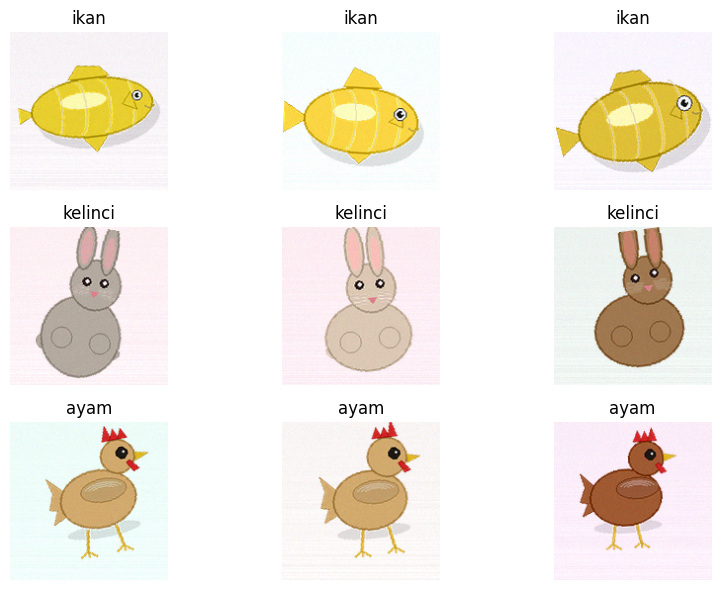

In [3]:
# 2. MENAMPILKAN CONTOH CITRA DATASET
# ==========================================================

plt.figure(figsize=(9, 6))
nomor = 1

for nama_kelas in KELAS_HEWAN:
    folder = os.path.join(BASE_DIR, nama_kelas)
    contoh_file = random.sample(os.listdir(folder), 3)

    for file in contoh_file:
        img_path = os.path.join(folder, file)
        img = Image.open(img_path)
        plt.subplot(3, 3, nomor)
        plt.imshow(img)
        plt.title(nama_kelas)
        plt.axis("off")
        nomor += 1

plt.tight_layout()
plt.show()

# ==========================================================

In [4]:
# 3. MEMBAGI DATASET MENJADI DATA TRAINING DAN VALIDASI
# ==========================================================

BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Nama kelas:", class_names)

# Optimasi pembacaan data agar training lebih cepat
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(600).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ==========================================================

Found 600 files belonging to 3 classes.
Using 480 files for training.
Found 600 files belonging to 3 classes.
Using 120 files for validation.
Nama kelas: ['ayam', 'ikan', 'kelinci']


In [5]:
# 4. MEMBUAT MODEL CNN SEDERHANA
# ==========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.12),
    layers.RandomContrast(0.12)
])

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.35),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================================================

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,283 (973.76 KB)

 Trainable params: 249,283 (973.76 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 5. MELATIH MODEL
# ==========================================================

EPOCHS = 15

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# ==========================================================

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3792 - loss: 1.1012 - val_accuracy: 0.3417 - val_loss: 1.0969
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.3875 - loss: 1.0611 - val_accuracy: 0.5583 - val_loss: 0.9108
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.5688 - loss: 0.8556 - val_accuracy: 0.4583 - val_loss: 1.0413
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6896 - loss: 0.7408 - val_accuracy: 0.7750 - val_loss: 0.5113
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8813 - loss: 0.3394 - val_accuracy: 0.9833 - val_loss: 0.1582
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9417 - loss: 0.1760 - val_accuracy: 0.9750 - val_loss: 0.0642
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9708 - loss: 0.1152 - val_accuracy: 0.8833 - val_loss: 0.3538
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9583 - loss: 0.2240 - val_accuracy: 0.9917 - val_loss:

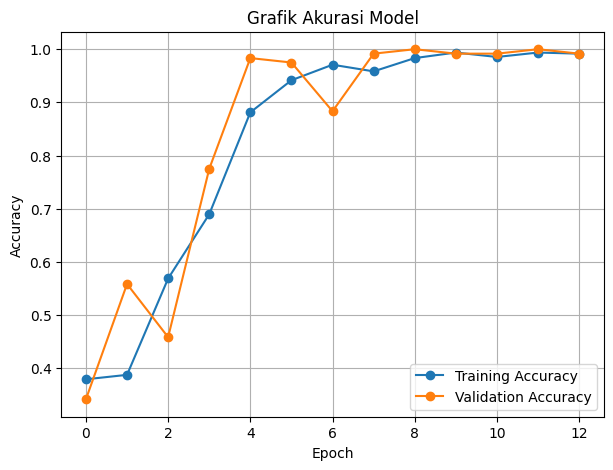

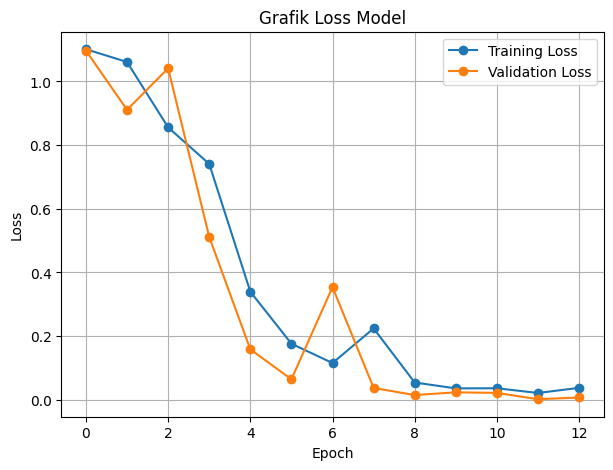

In [7]:
# 6. MENAMPILKAN GRAFIK AKURASI DAN LOSS
# ==========================================================

plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Grafik Akurasi Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Grafik Loss Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================

In [8]:
# 7. EVALUASI MODEL
# ==========================================================

loss, accuracy = model.evaluate(val_ds)
print("Validation Loss:", round(loss, 4))
print("Validation Accuracy:", round(accuracy, 4))

# ==========================================================

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 410ms/step - accuracy: 1.0000 - loss: 0.0146
Validation Loss: 0.0146
Validation Accuracy: 1.0


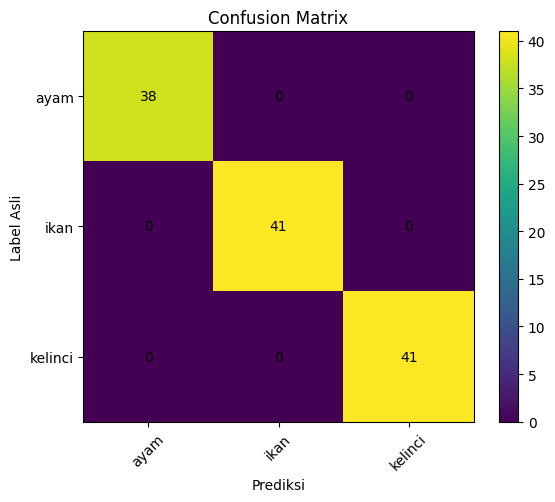

In [9]:
# 8. MEMBUAT CONFUSION MATRIX
# ==========================================================

y_true = []
y_pred = []

for gambar, label in val_ds:
    prediksi = model.predict(gambar, verbose=0)
    y_true.extend(label.numpy())
    y_pred.extend(np.argmax(prediksi, axis=1))

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Label Asli")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# ==========================================================

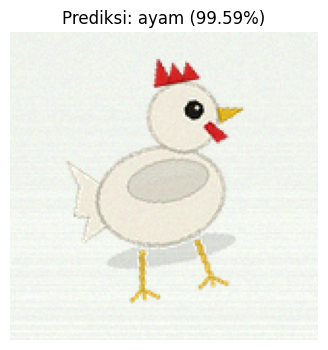

File gambar: /content/dataset_hewan/ayam/ayam_001.png
Hasil prediksi: ayam
Confidence: 99.59%
Skor semua kelas:
- ayam: 99.59%
- ikan: 0.09%
- kelinci: 0.31%


In [11]:
# 9. PREDIKSI SATU GAMBAR
# ==========================================================
# Perbaikan penting:
# Pada model sudah ada Dense(..., activation="softmax").
# Jadi hasil model.predict() sudah berupa probabilitas.
# Jangan diberi tf.nn.softmax lagi, karena bisa membuat nilai confidence menjadi salah.


def prediksi_gambar(gambar_path):
    img = tf.keras.utils.load_img(gambar_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    skor = model.predict(img_array, verbose=0)[0]

    index_tertinggi = int(np.argmax(skor))
    label_prediksi = class_names[index_tertinggi]
    confidence = 100 * float(np.max(skor))

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {label_prediksi} ({confidence:.2f}%)")
    plt.show()

    print("File gambar:", gambar_path)
    print("Hasil prediksi:", label_prediksi)
    print("Confidence:", f"{confidence:.2f}%")

    # Menampilkan semua skor kelas agar mahasiswa bisa melihat perbandingan
    print("Skor semua kelas:")
    for nama_kelas, nilai in zip(class_names, skor):
        print(f"- {nama_kelas}: {nilai * 100:.2f}%")

# Contoh uji menggunakan salah satu gambar dari dataset
contoh_path = os.path.join(BASE_DIR, "ayam", "ayam_001.png")
prediksi_gambar(contoh_path)

# ==========================================================

Saving 9570217949198568.webp to 9570217949198568.webp


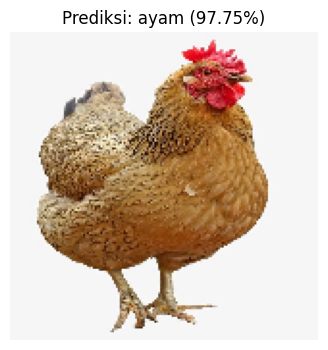

File gambar: 9570217949198568.webp
Hasil prediksi: ayam
Confidence: 97.75%
Skor semua kelas:
- ayam: 97.75%
- ikan: 2.25%
- kelinci: 0.00%


In [12]:
# 10. OPSIONAL: UPLOAD GAMBAR DARI KOMPUTER MAHASISWA
# ==========================================================
# Jalankan cell ini jika ingin menguji gambar buah dari komputer.
# Tips: pakai gambar yang jelas, 1 hewan saja, latar tidak terlalu ramai.

from google.colab import files

uploaded = files.upload()

for nama_file in uploaded.keys():
    prediksi_gambar(nama_file)

# ==========================================================

In [14]:
# 11. MENYIMPAN MODEL
# ==========================================================

model.save("/content/model_klasifikasi_hewan_cnn_v2.keras")
print("Model berhasil disimpan: /content/model_klasifikasi_hewan_cnn_v2.keras")

Model berhasil disimpan: /content/model_klasifikasi_hewan_cnn_v2.keras
